## CNN Text Classification on Handwritten Digits

In [ ]:
# import libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import plot_model

import matplotlib.pyplot as plt

In [ ]:
# loading the dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Add channel dimension (important for CNN)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# building CNN model
def build_cnn(stride = 1, pooling_type = 'max', num_filters = 32):

    if pooling_type == 'max':
        pooling = layers.MaxPooling2D((2,2))
    else:
        pooling = layers.AveragePooling2D((2,2))

    model = keras.Sequential([
        layers.Conv2D(num_filters, kernel_size = (3,3), strides = stride, padding = 'same', activation = 'relu', input_shape = (28,28,1)),
        pooling,

        layers.Conv2D(num_filters*2, kernel_size = (3,3), strides = stride, padding = 'same', activation = 'relu'),
        pooling,

        layers.Flatten(),

        layers.Dense(128, activation = 'relu'),
        layers.Dense(10, activation = 'softmax')
    ])

    model.compile(
        optimizer = 'adam',
        loss = 'sparse_categorical_crossentropy',
        metrics = ['accuracy'])

    return model

In [ ]:
# training of Cnn model
model = build_cnn()

history = model.fit(
    X_train, y_train, validation_split = 0.2, epochs = 5, batch_size = 64)

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 57s 74ms/step - accuracy: 0.9465 - loss: 0.1776 - val_accuracy: 0.9800 - val_loss: 0.0658
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 71ms/step - accuracy: 0.9847 - loss: 0.0512 - val_accuracy: 0.9796 - val_loss: 0.0648
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 51s 68ms/step - accuracy: 0.9894 - loss: 0.0342 - val_accuracy: 0.9872 - val_loss: 0.0411
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 53s 71ms/step - accuracy: 0.9920 - loss: 0.0257 - val_accuracy: 0.9889 - val_loss: 0.0370
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 57s 76ms/step - accuracy: 0.9941 - loss: 0.0183 - val_accuracy: 0.9881 - val_loss: 0.0421
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9900 - loss: 0.0296
Test Accuracy: 0.9900000095367432


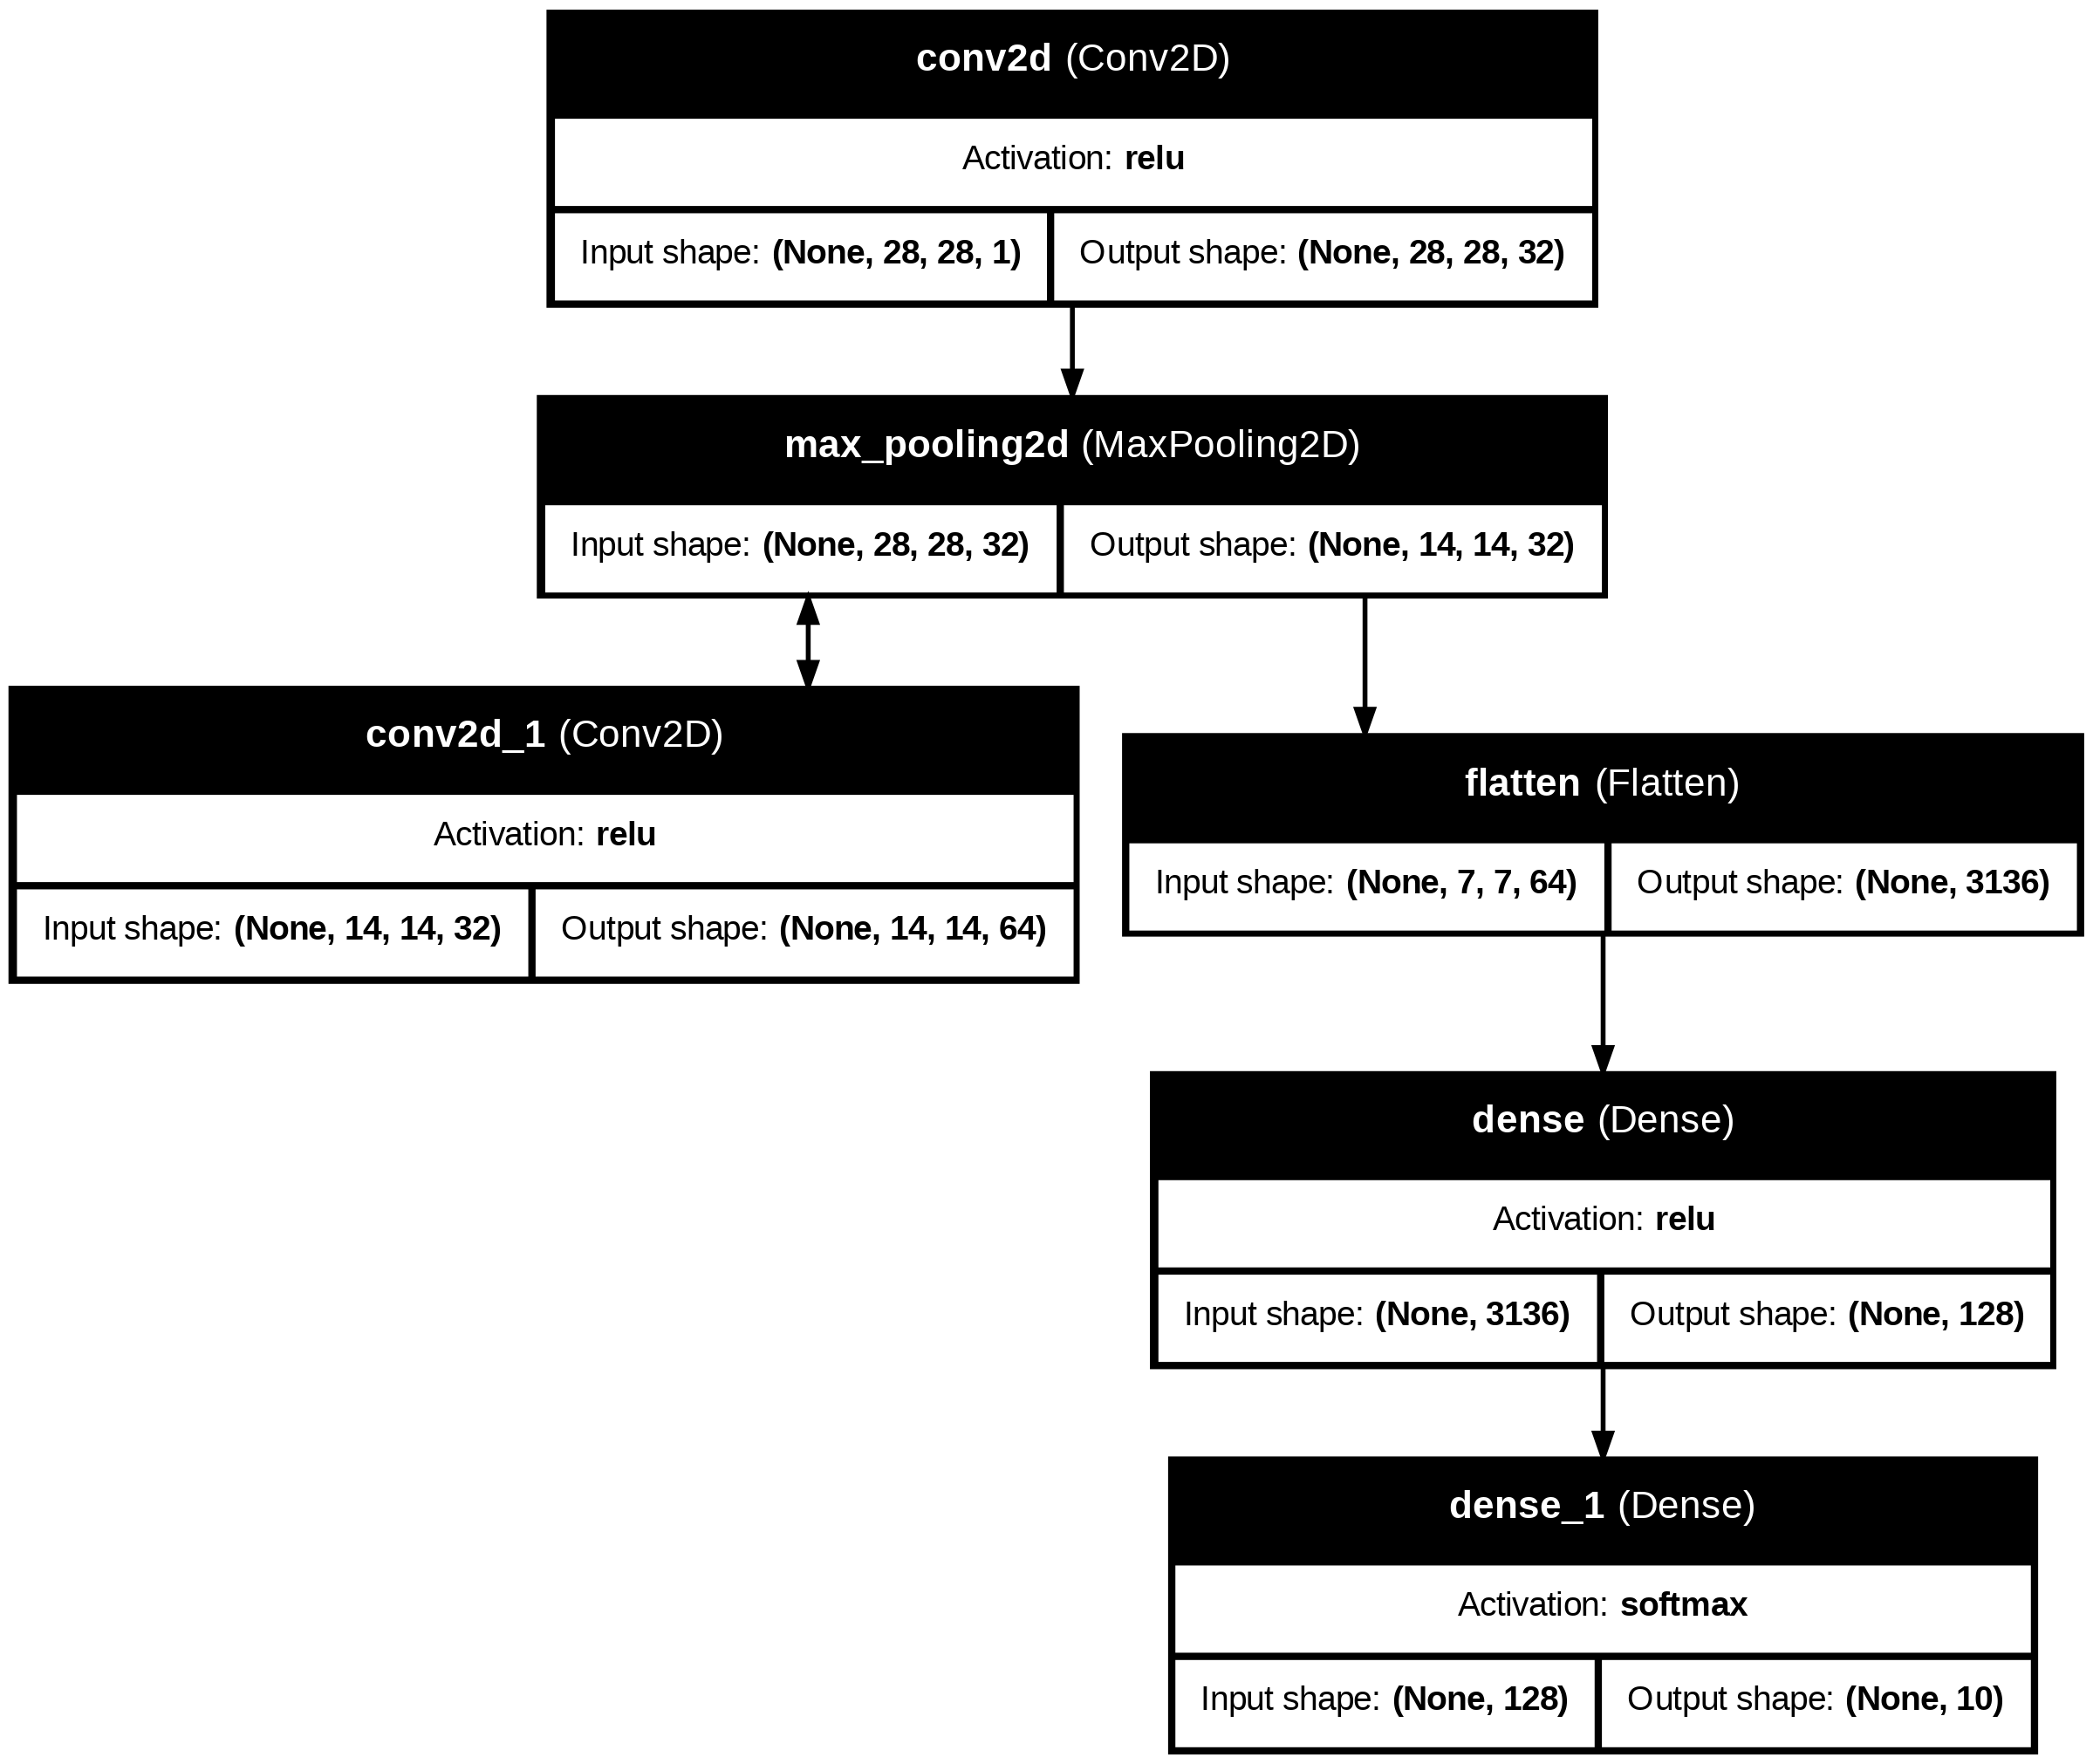

In [ ]:
# plotting the architecture of model
plot_model(model, show_shapes = True, show_layer_names = True, show_layer_activations = True)

In [ ]:
# changing the stride
model_stride = build_cnn(stride=2)

model_stride.fit(X_train, y_train, epochs = 5, validation_split = 0.2)

loss, acc = model_stride.evaluate(X_test, y_test)
print("Accuracy with stride=2:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9162 - loss: 0.2720 - val_accuracy: 0.9693 - val_loss: 0.1002
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9709 - loss: 0.0929 - val_accuracy: 0.9776 - val_loss: 0.0757
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9793 - loss: 0.0665 - val_accuracy: 0.9781 - val_loss: 0.0710
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9830 - loss: 0.0537 - val_accuracy: 0.9817 - val_loss: 0.0605
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9868 - loss: 0.0429 - val_accuracy: 0.9811 - val_loss: 0.0632
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9834 - loss: 0.0520
Accuracy with stride=2: 0.9833999872207642


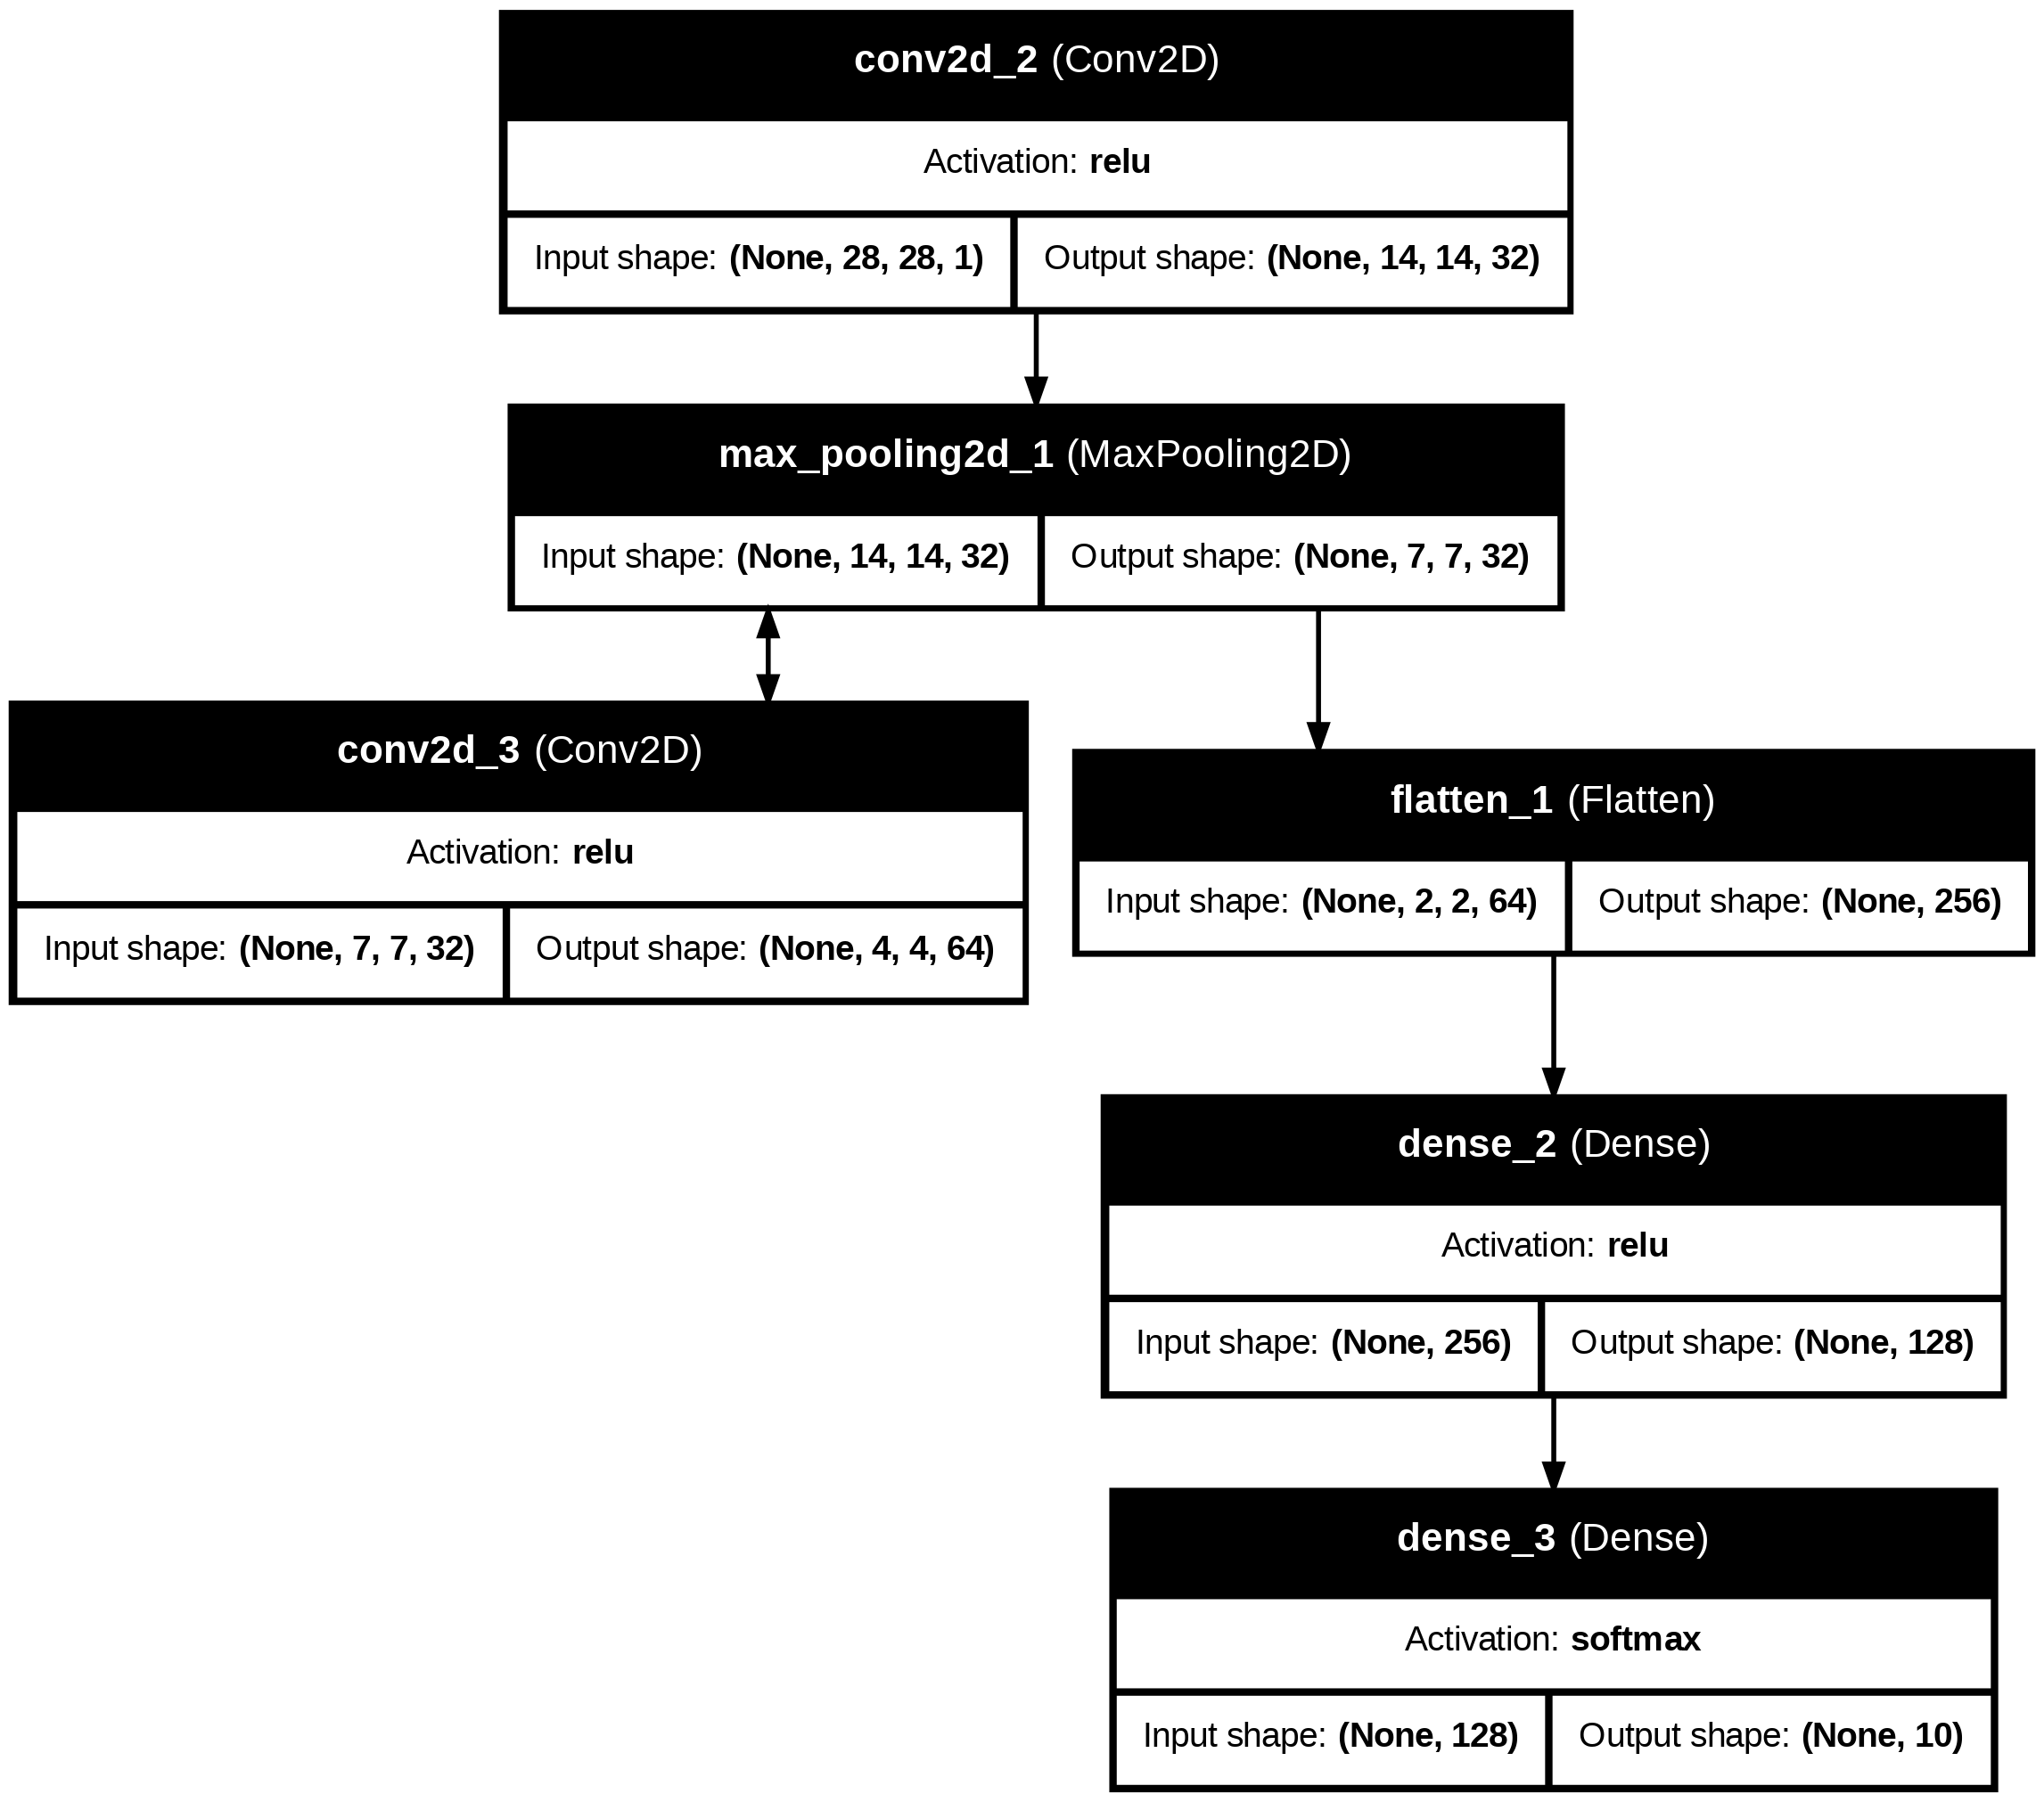

In [ ]:
# plotting the architecture of model
plot_model(model_stride, show_shapes = True, show_layer_names = True, show_layer_activations = True)

In [ ]:
# comparing the MAX POOLING and AVERAGE POOLING
# Max Pooling
model_max = build_cnn(pooling_type = 'max')
model_max.fit(X_train, y_train, epochs = 5, validation_split = 0.2)
acc_max = model_max.evaluate(X_test, y_test)[1]

# Average Pooling
model_avg = build_cnn(pooling_type='avg')
model_avg.fit(X_train, y_train, epochs=5, validation_split=0.2)
acc_avg = model_avg.evaluate(X_test, y_test)[1]

print("Max Pool Accuracy:", acc_max)
print("Avg Pool Accuracy:", acc_avg)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.9548 - loss: 0.1461 - val_accuracy: 0.9816 - val_loss: 0.0613
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 40ms/step - accuracy: 0.9857 - loss: 0.0466 - val_accuracy: 0.9835 - val_loss: 0.0524
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 38ms/step - accuracy: 0.9907 - loss: 0.0299 - val_accuracy: 0.9877 - val_loss: 0.0427
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.9926 - loss: 0.0222 - val_accuracy: 0.9895 - val_loss: 0.0367
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 61s 41ms/step - accuracy: 0.9941 - loss: 0.0171 - val_accuracy: 0.9869 - val_loss: 0.0469
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9868 - loss: 0.0426
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.9475 - loss: 0.1721 - val_accuracy: 0.9803 - val_loss: 0.0660
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9824 - loss: 0.0567 - val_accuracy: 0.9868 - val_loss: 0.0463
Epoch 3

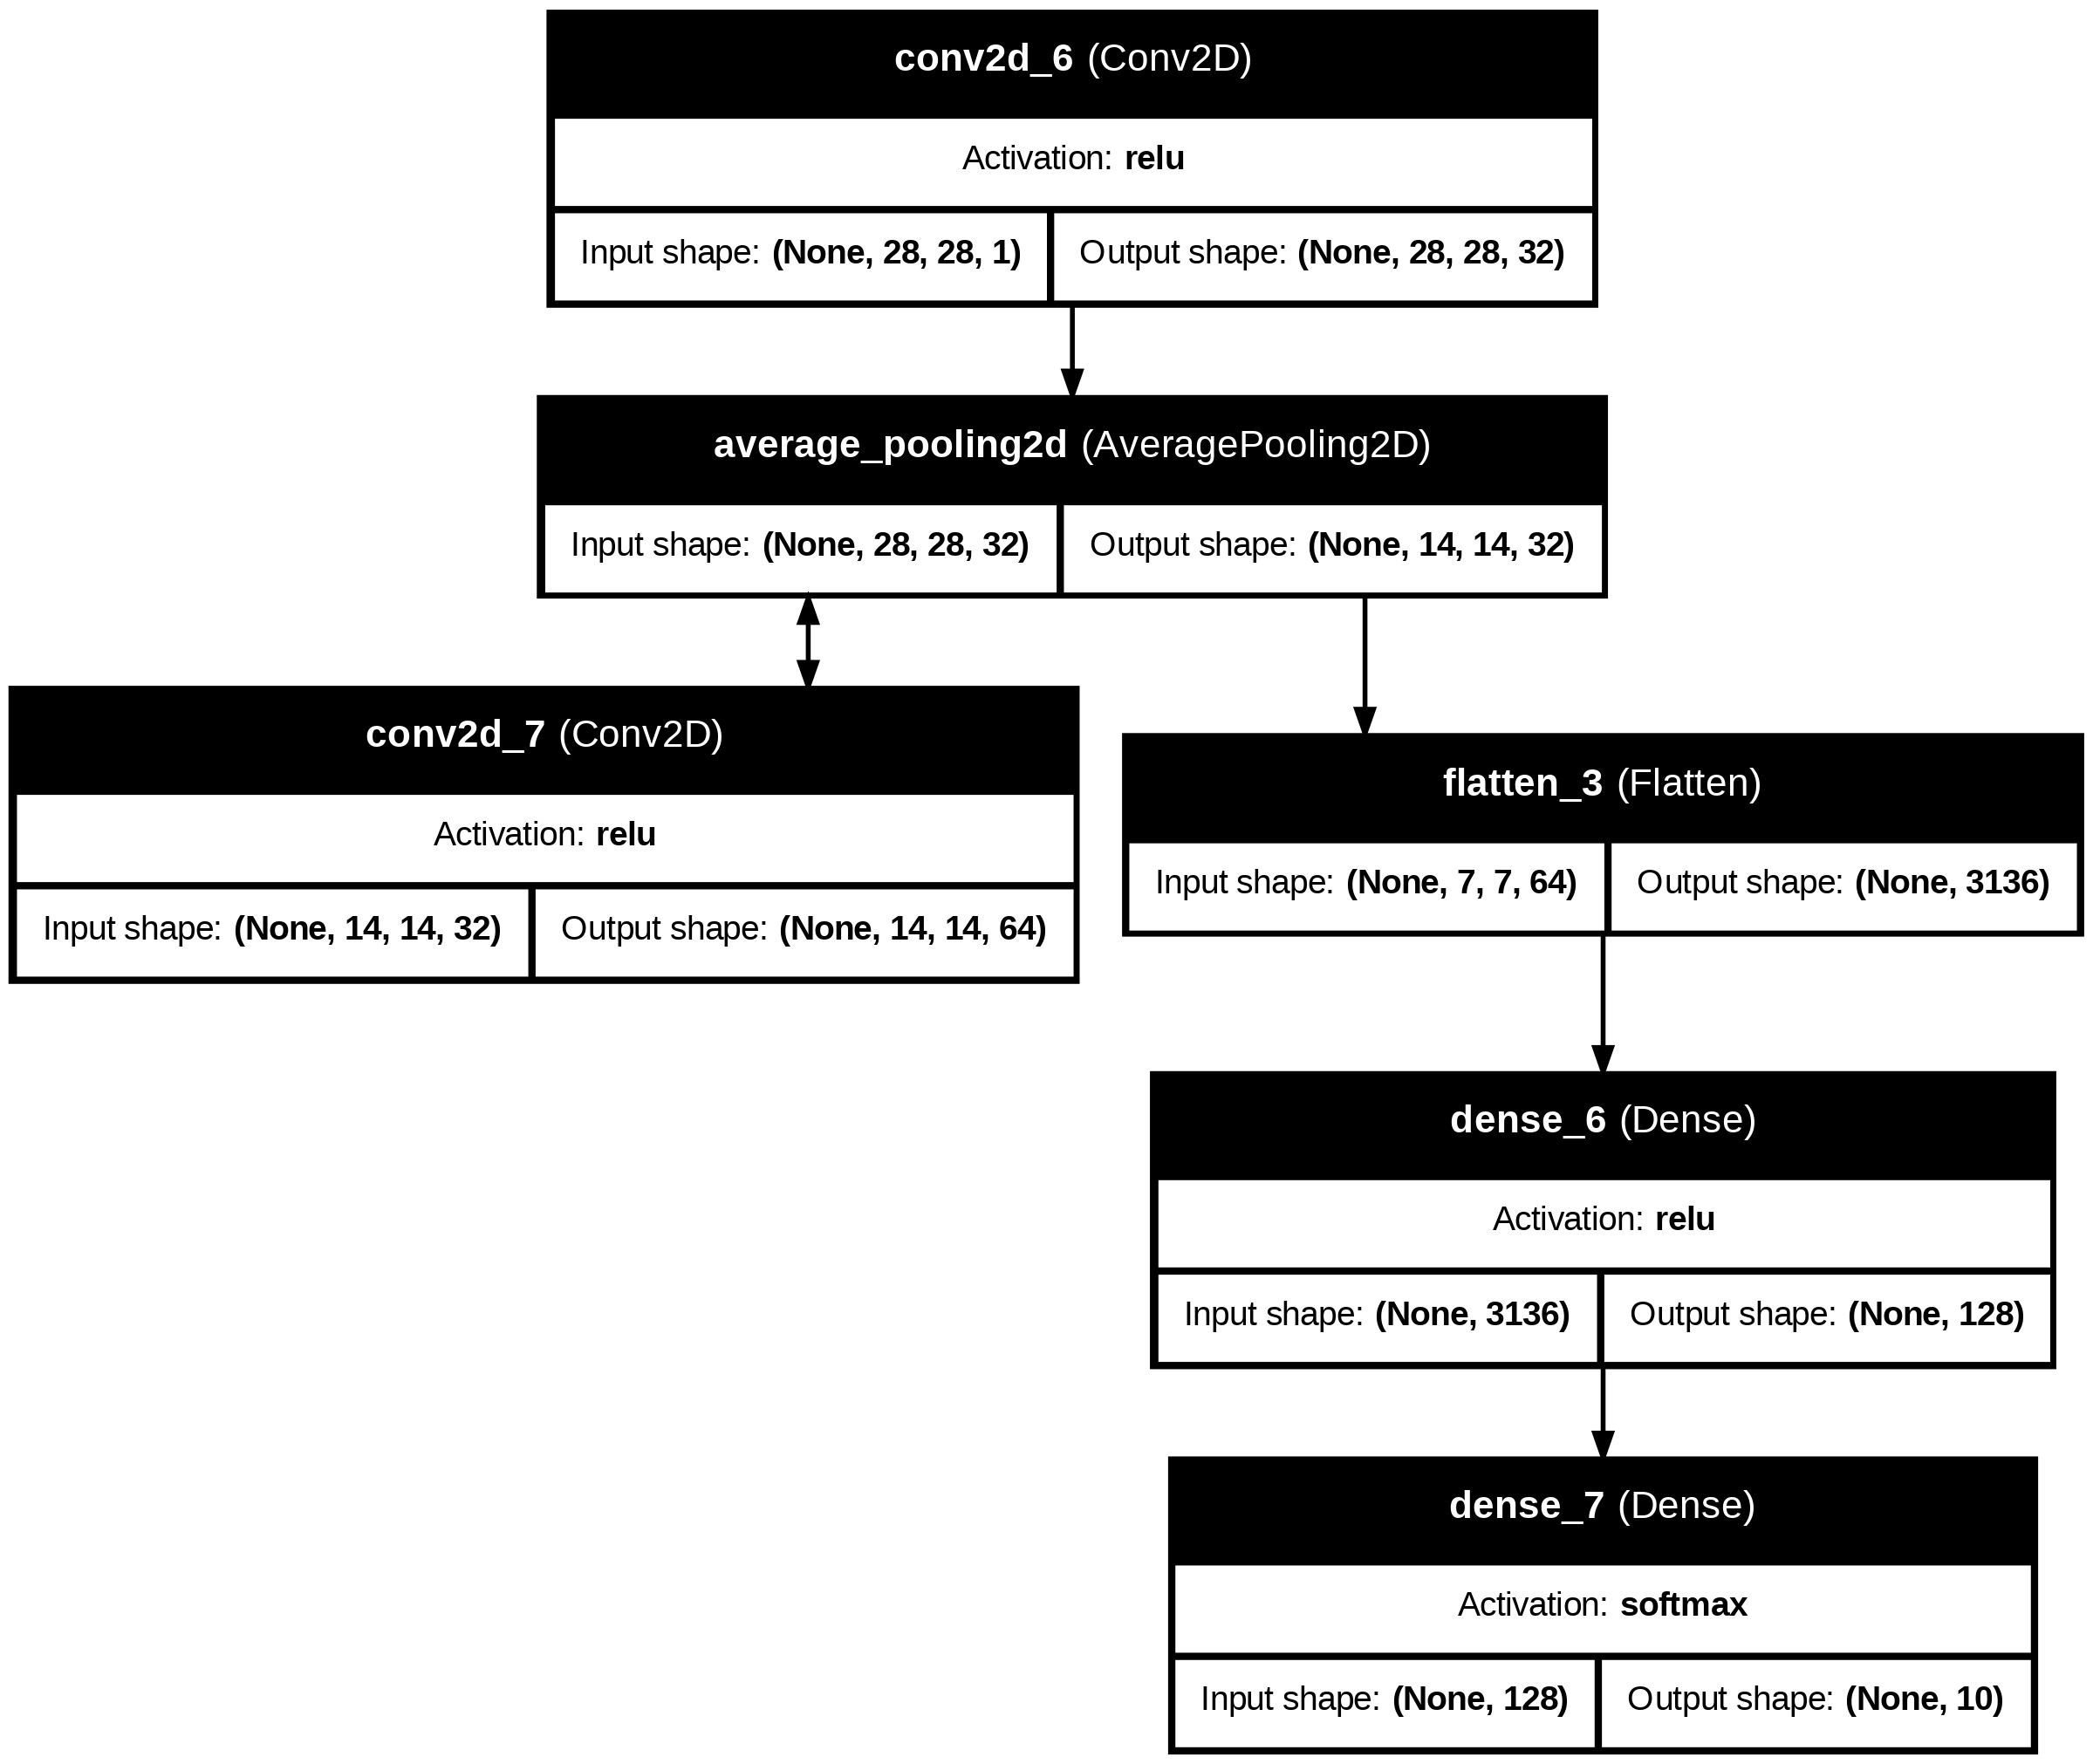

In [ ]:
# plotting the architecture of model
plot_model(model_avg, show_shapes = True, show_layer_names = True, show_layer_activations = True)

In [ ]:
# increasing the filters
model_filters = build_cnn(num_filters=64)

model_filters.fit(X_train, y_train, epochs = 5, validation_split = 0.2)

loss, acc = model_filters.evaluate(X_test, y_test)
print("Accuracy with more filters:", acc)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 148s 97ms/step - accuracy: 0.9623 - loss: 0.1232 - val_accuracy: 0.9831 - val_loss: 0.0570
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 142s 95ms/step - accuracy: 0.9877 - loss: 0.0398 - val_accuracy: 0.9888 - val_loss: 0.0379
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 204s 96ms/step - accuracy: 0.9913 - loss: 0.0265 - val_accuracy: 0.9903 - val_loss: 0.0367
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 200s 95ms/step - accuracy: 0.9941 - loss: 0.0179 - val_accuracy: 0.9882 - val_loss: 0.0448
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 204s 96ms/step - accuracy: 0.9952 - loss: 0.0146 - val_accuracy: 0.9894 - val_loss: 0.0375
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9905 - loss: 0.0315
Accuracy with more filters: 0.9904999732971191


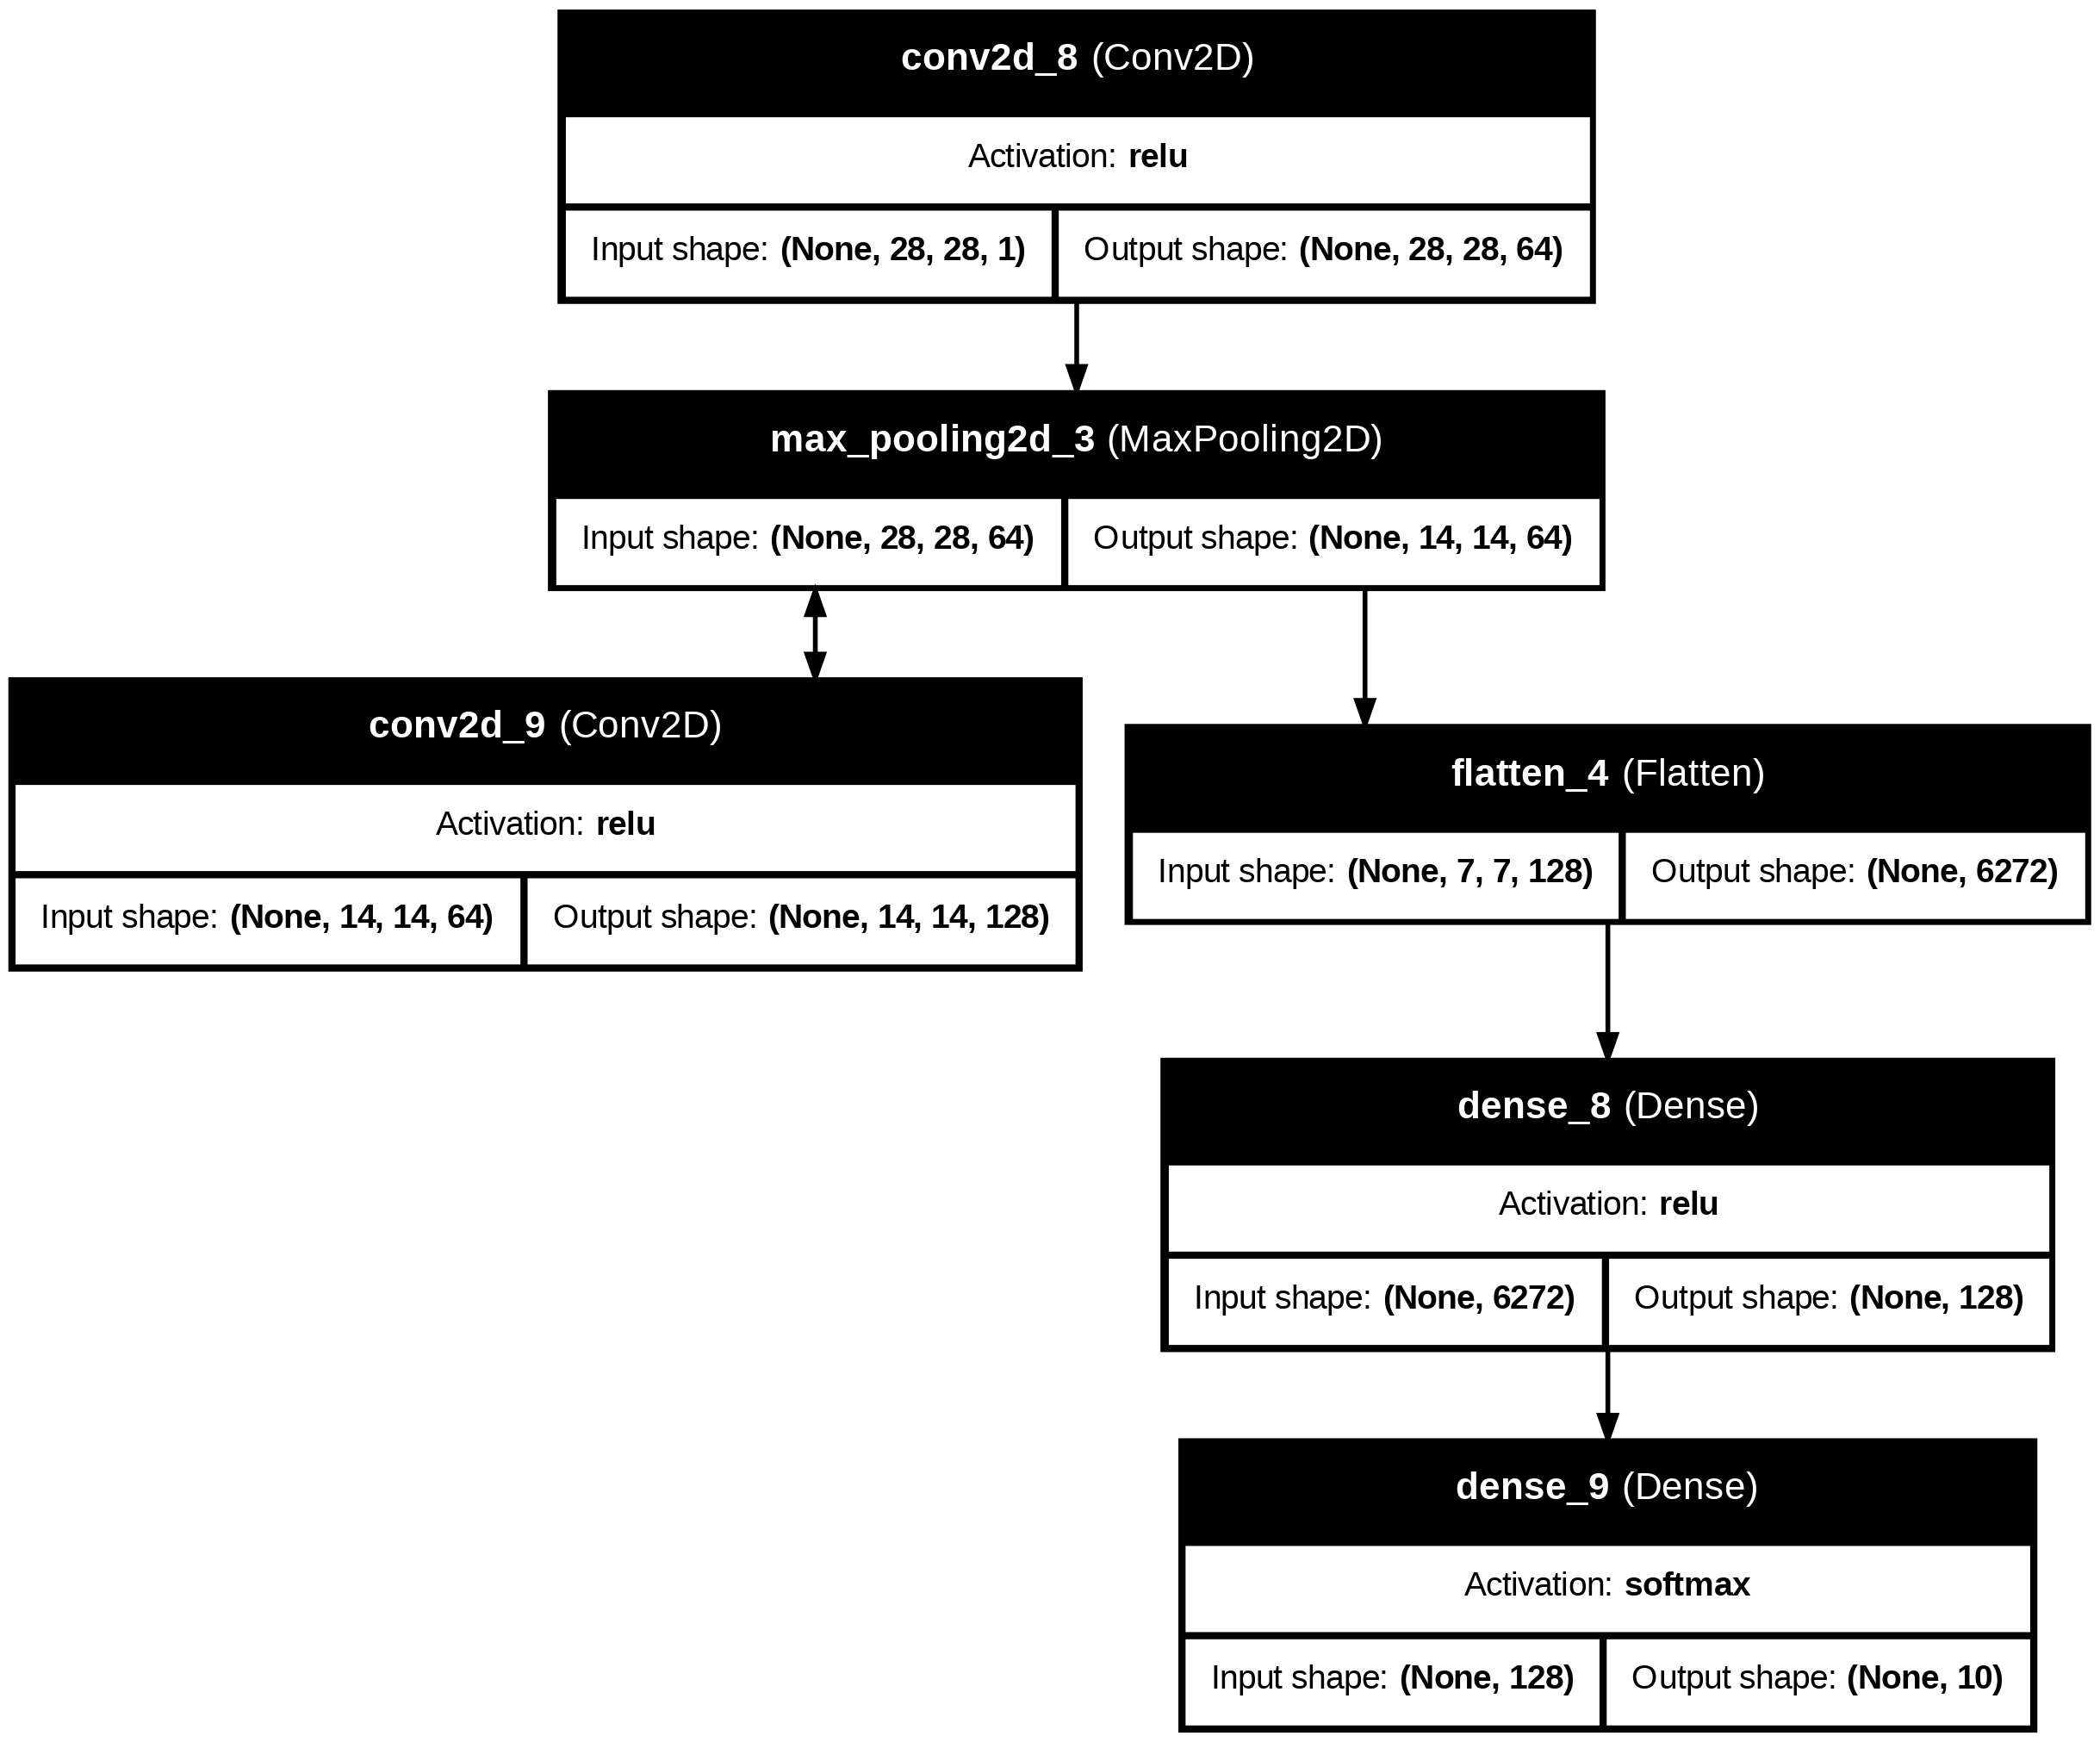

In [ ]:
# plotting the architecture of model
plot_model(model_filters, show_shapes = True, show_layer_names = True, show_layer_activations = True)

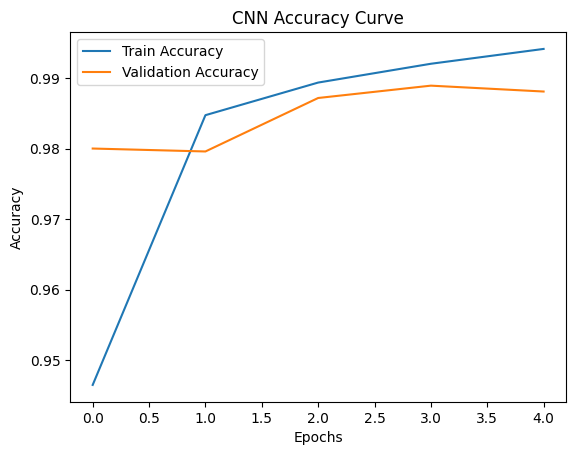

In [ ]:
# plotting accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Accuracy Curve")
plt.show()